# MaldiAMRKit - Exploration & Similarity

This notebook demonstrates how to use MaldiAMRKit's exploratory visualization
and spectral similarity functions to inspect MALDI-TOF datasets before building
classifiers.

It covers:
- **PCA** scatter plots colored by metadata
- **t-SNE** embeddings
- **UMAP** embeddings (requires `pip install maldiamrkit[batch]`)
- **Spectral similarity**: pairwise distance matrices, heatmaps, clustering, and dendrograms
- Brief introduction to **batch effect correction** with `combatlearn`

In [1]:
from maldiamrkit import MaldiSet
from maldiamrkit.visualization import plot_pca, plot_tsne

/home/ettore/.venvs/maldiamrkit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the Dataset

Load the example dataset bundled with MaldiAMRKit (29 spectra with
resistance labels).

In [2]:
data = MaldiSet.from_directory(
    "../data/",
    "../data/metadata/metadata.csv",
    aggregate_by=dict(antibiotics="Drug"),
    bin_width=3,
)
print(data)

MaldiSet(n_spectra=29, species='all', antibiotics=['Drug'])


In [3]:
labels = data.get_y_single("Drug")
print(f"Samples: {data.X.shape[0]}, Features: {data.X.shape[1]}")
print(f"Labels: {labels.value_counts().to_dict()}")

Samples: 29, Features: 6000
Labels: {'S': 19, 'R': 10}


## PCA

PCA is the simplest starting point. Axis labels automatically show
the explained variance percentage.

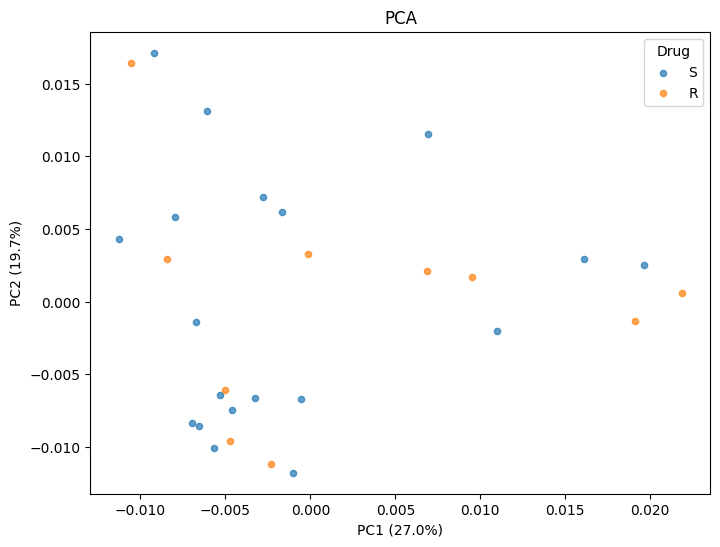

In [4]:
_ = plot_pca(data.X, color_by=labels)

You can pass any matplotlib keyword arguments through `**pca_kwargs`,
or provide a custom palette:

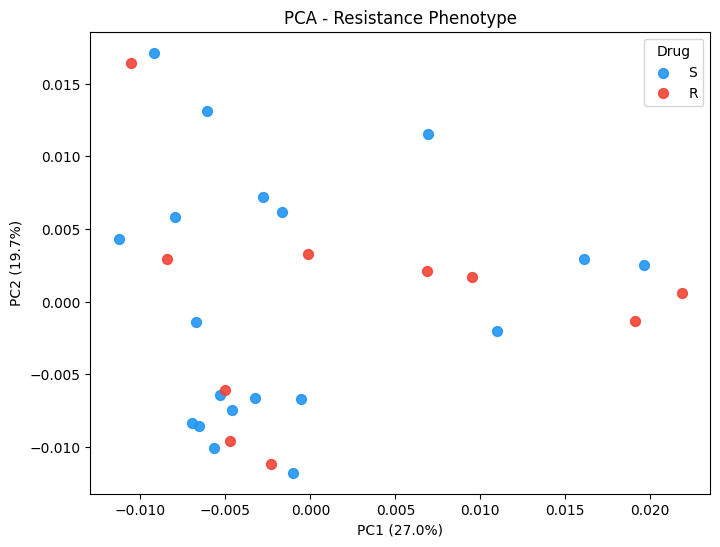

In [5]:
_ = plot_pca(
    data.X,
    color_by=labels,
    palette={"S": "#2196F3", "R": "#F44336"},
    title="PCA - Resistance Phenotype",
    alpha=0.9,
    s=50,
)

## t-SNE

For a non-linear embedding, use `plot_tsne`. With only 29 samples,
set `perplexity` low.

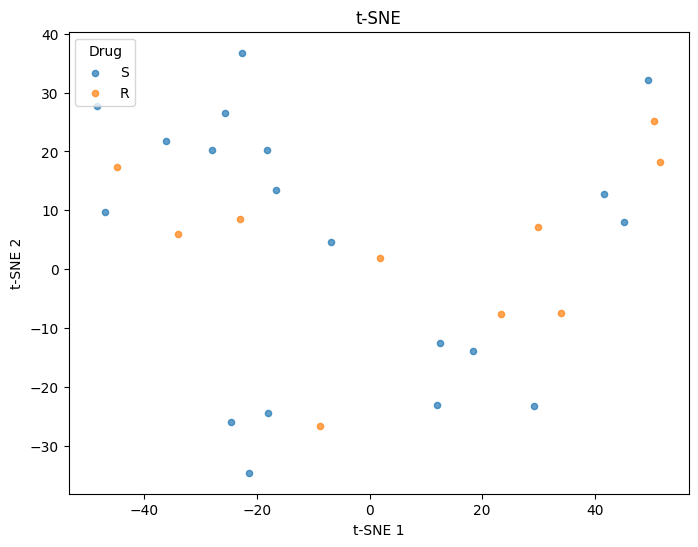

In [6]:
_ = plot_tsne(data.X, color_by=labels, perplexity=5)

## UMAP

UMAP requires the optional `umap-learn` package:

```bash
pip install maldiamrkit[batch]
```

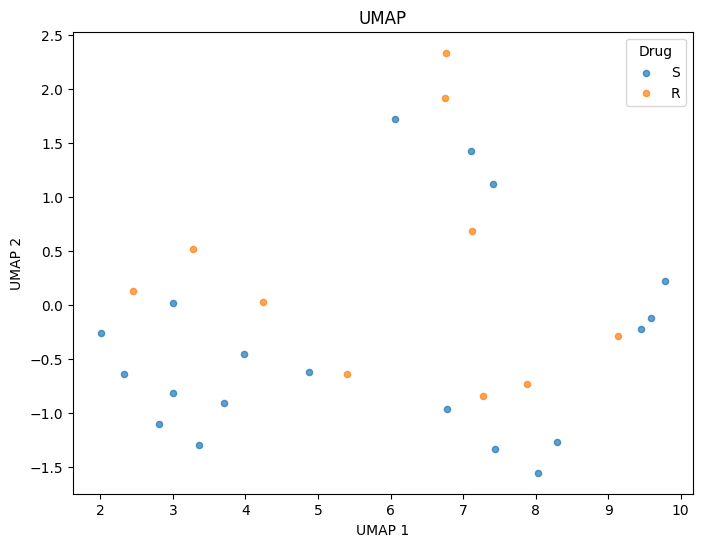

In [7]:
try:
    from maldiamrkit.visualization import plot_umap

    _ = plot_umap(data.X, color_by=labels, n_neighbors=5)
except ImportError as e:
    print(e)

## Spectral Similarity

MaldiAMRKit provides spectral distance metrics, pairwise distance matrix
computation, clustering algorithms, and dedicated plots for similarity
analysis.

Available metrics (see `SpectralMetric`):
- **cosine** - cosine distance (binned spectra)
- **spectral_contrast_angle** - spectral contrast angle (binned spectra)
- **pearson** - 1 − Pearson correlation (binned spectra)
- **wasserstein** - Wasserstein / earth mover's distance (raw spectra)
- **dtw** - dynamic time warping distance (raw spectra)

In [8]:
from maldiamrkit.similarity import (
    cluster_metadata_concordance,
    cluster_spectra,
    hierarchical_clustering,
    pairwise_distances,
    plot_dendrogram,
    plot_distance_heatmap,
    silhouette_scores,
)

### Pairwise Distance Matrix

Compute a symmetric distance matrix from the binned feature matrix.
For binned spectra, cosine distance is a natural choice.

In [9]:
D = pairwise_distances(data.X, metric="cosine")
print(f"Distance matrix shape: {D.shape}")
print(f"Range: [{D[D > 0].min():.4f}, {D.max():.4f}]")

Distance matrix shape: (29, 29)
Range: [0.0457, 0.7392]


### Distance Heatmap

Visualize the pairwise distance matrix. Darker values indicate more
similar spectra.

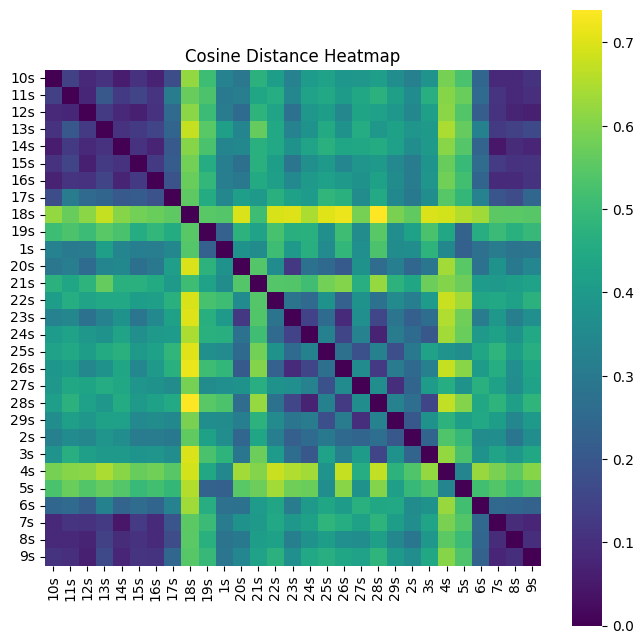

In [10]:
sample_ids = data.X.index.tolist()
_ = plot_distance_heatmap(D, labels=sample_ids, title="Cosine Distance Heatmap")

### Hierarchical Clustering & Dendrogram

Build a linkage matrix and visualize the cluster hierarchy.

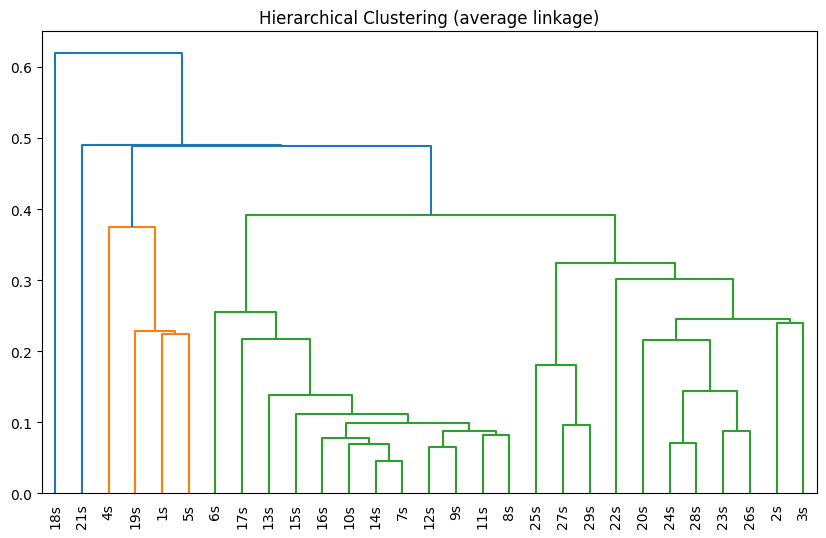

In [11]:
linkage = hierarchical_clustering(D, method="average")
_ = plot_dendrogram(
    linkage, labels=sample_ids, title="Hierarchical Clustering (average linkage)"
)

### Cluster Assignment & Evaluation

Use `cluster_spectra` for a one-call clustering workflow. Then evaluate
how well the clusters align with known resistance labels using
silhouette scores and metadata concordance (ARI, NMI).

In [12]:
import pandas as pd

cluster_labels = cluster_spectra(D, method="hierarchical", n_clusters=2)

# Internal validation: silhouette score
sil = silhouette_scores(D, cluster_labels)
print(f"Silhouette score: {sil:.3f}")

# External validation: agreement with resistance phenotype
concordance = cluster_metadata_concordance(cluster_labels, labels)
print(f"Adjusted Rand Index:       {concordance['adjusted_rand_index']:.3f}")
print(f"Normalized Mutual Info:    {concordance['normalized_mutual_info']:.3f}")

# Cross-tabulate clusters vs resistance labels
ct = pd.crosstab(
    pd.Series(cluster_labels, index=labels.index, name="Cluster"),
    labels,
)
ct

Silhouette score: 0.400
Adjusted Rand Index:       -0.032
Normalized Mutual Info:    0.038


Drug,R,S
Cluster,,
1,10,18
2,0,1


### Comparing Metrics

Try different distance metrics to see which one separates the
resistance phenotypes best.

In [13]:
results = []
for metric in ["cosine", "spectral_contrast_angle", "pearson"]:
    D_m = pairwise_distances(data.X, metric=metric)
    cl = cluster_spectra(D_m, method="hierarchical", n_clusters=2)
    sil_m = silhouette_scores(D_m, cl)
    conc_m = cluster_metadata_concordance(cl, labels)
    results.append(
        {
            "metric": metric,
            "silhouette": sil_m,
            "ARI": conc_m["adjusted_rand_index"],
            "NMI": conc_m["normalized_mutual_info"],
        }
    )

pd.DataFrame(results).set_index("metric")

,silhouette,ARI,NMI
metric,,,
cosine,0.400211,-0.032362,0.037532
spectral_contrast_angle,0.262259,-0.032362,0.037532
pearson,0.412520,-0.032362,0.037532


## Batch Effect Correction

When combining data from multiple sites or instruments, batch effects
can dominate the signal. Use
[combatlearn](https://github.com/EttoreRocchi/combatlearn) for
ComBat-based harmonization:

```python
from combatlearn import Combat

combat = Combat(method="fortin")
combat.fit(X, y=batch_labels)
X_corrected = combat.transform(X, y=batch_labels)
```

Install with `pip install maldiamrkit[batch]`.
See the [combatlearn documentation](https://combatlearn.readthedocs.io/)
for full usage.

> Rocchi, E., Nicitra, E., Calvo, M. et al. *Combining mass spectrometry
> and machine learning models for predicting Klebsiella pneumoniae
> antimicrobial resistance: a multicenter experience from clinical
> isolates in Italy*. **BMC Microbiol** (2026).
> [doi:10.1186/s12866-025-04657-2](https://link.springer.com/article/10.1186/s12866-025-04657-2)